In [4]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

# Data Understanding

In [5]:
df = pd.read_excel("premiums_young_with_gr.xlsx")

df.head()

,Age,Gender,Region,Marital_status,Number Of Dependants,BMI_Category,Smoking_Status,Employment_Status,Income_Level,Income_Lakhs,Medical History,Insurance_Plan,Annual_Premium_Amount,Genetical_Risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [6]:
df.shape

(20096, 14)

In [7]:
print(f"Rows:- {df.shape[0]} \nColumns:- {df.shape[1]}")

Rows:- 20096 
Columns:- 14


In [8]:
df.columns

Index(['Age', 'Gender', 'Region', 'Marital_status', 'Number Of Dependants',
       'BMI_Category', 'Smoking_Status', 'Employment_Status', 'Income_Level',
       'Income_Lakhs', 'Medical History', 'Insurance_Plan',
       'Annual_Premium_Amount', 'Genetical_Risk'],
      dtype='object')

In [9]:
df.columns.str.replace(" ","_").str.lower()

Index(['age', 'gender', 'region', 'marital_status', 'number_of_dependants',
       'bmi_category', 'smoking_status', 'employment_status', 'income_level',
       'income_lakhs', 'medical_history', 'insurance_plan',
       'annual_premium_amount', 'genetical_risk'],
      dtype='object')

In [10]:
df.columns = df.columns.str.replace(" ","_").str.lower().copy()

df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


# Data Cleaning 

### Looking for Null Values 

In [11]:
df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           2
employment_status        1
income_level             4
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [12]:
df.dropna(inplace=True)

df.isna().sum()

age                      0
gender                   0
region                   0
marital_status           0
number_of_dependants     0
bmi_category             0
smoking_status           0
employment_status        0
income_level             0
income_lakhs             0
medical_history          0
insurance_plan           0
annual_premium_amount    0
genetical_risk           0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df.drop_duplicates(inplace=True)
df.duplicated().sum()

np.int64(0)

In [15]:
df.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20090.000000,20090.000000,20090.000000,20090.000000,20090.000000
mean,21.494375,0.718019,22.510851,8142.096267,2.503932
std,2.294052,0.940713,23.420493,2749.906347,1.710203
min,18.000000,-3.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.250000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,790.000000,18186.000000,5.000000


Min Number of dependent is negative ,max age is 356 , max income is 930 

In [16]:
df[df.number_of_dependants<0].shape[0]

22

In [17]:
df[df.number_of_dependants<0]["number_of_dependants"].unique()

array([-3, -1])

Converting this to Positive Value 

In [18]:
df["number_of_dependants"] = df["number_of_dependants"].abs()

df["number_of_dependants"].describe()

count    20090.000000
mean         0.722598
std          0.937200
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          3.000000
Name: number_of_dependants, dtype: float64

### Finding Outliers using Boxplot

In [19]:
df.skew(numeric_only=True)

age                      0.000906
number_of_dependants     1.130682
income_lakhs             5.184819
annual_premium_amount    0.645243
genetical_risk          -0.008882
dtype: float64

In [20]:
df.kurt(numeric_only=True)

age                       -1.234395
number_of_dependants       0.225525
income_lakhs             114.235252
annual_premium_amount      0.165836
genetical_risk            -1.271263
dtype: float64

There are Many Outliers in our dataset ( specially in age and income column ) which we have to deal with 

In [21]:
df.dtypes

age                       int64
gender                   object
region                   object
marital_status           object
number_of_dependants      int64
bmi_category             object
smoking_status           object
employment_status        object
income_level             object
income_lakhs              int64
medical_history          object
insurance_plan           object
annual_premium_amount     int64
genetical_risk            int64
dtype: object

In [22]:
numerical_columns= df.select_dtypes(["int64"]).columns

numerical_columns

Index(['age', 'number_of_dependants', 'income_lakhs', 'annual_premium_amount',
       'genetical_risk'],
      dtype='object')

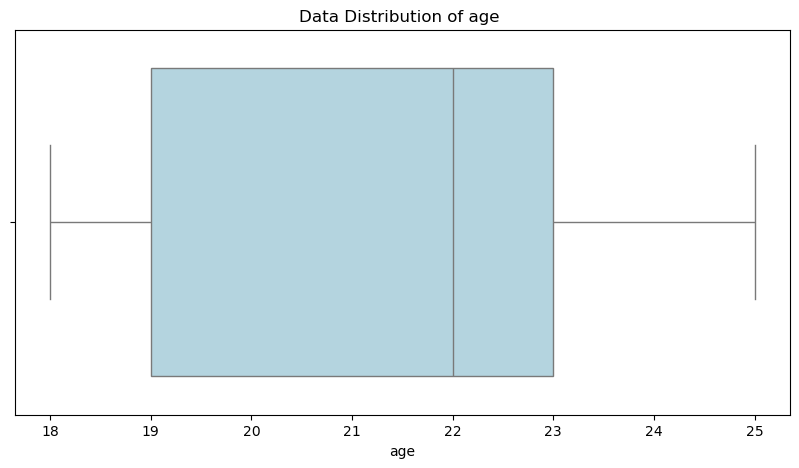

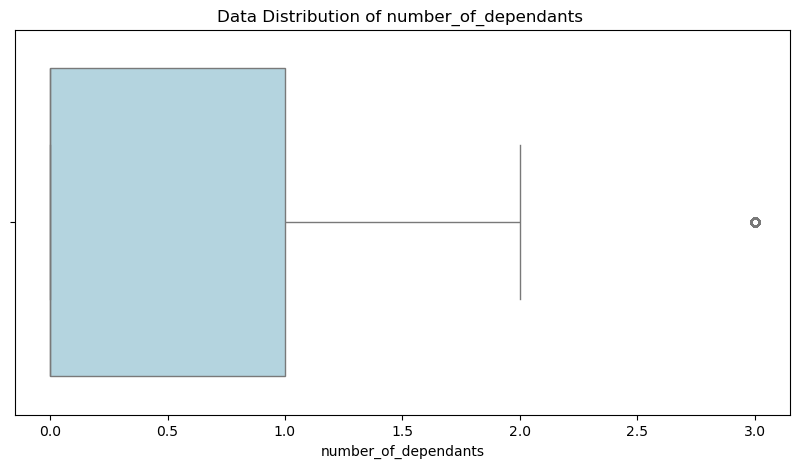

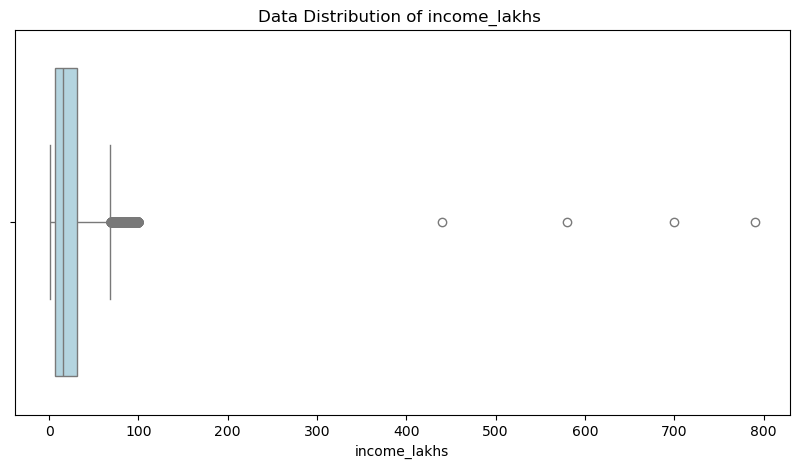

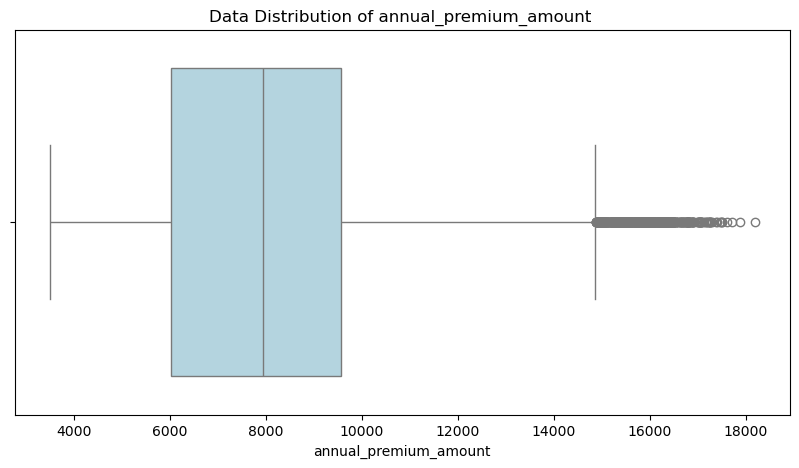

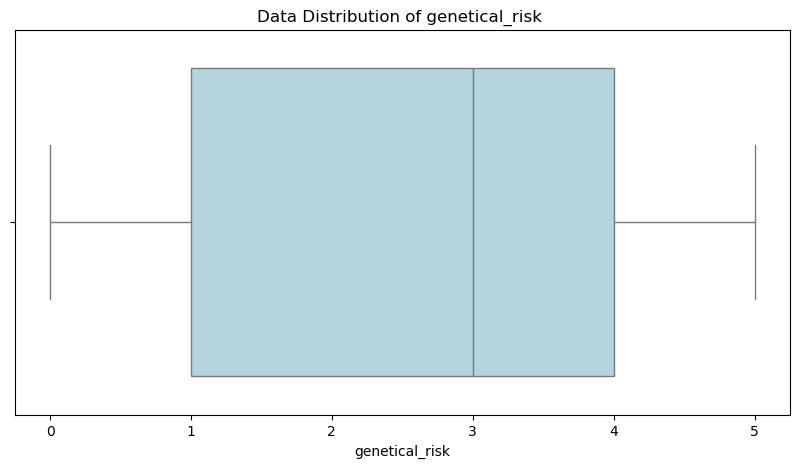

In [23]:
for i in numerical_columns:
    plt.figure(figsize=(10, 5))
    sns.boxplot(x=df[i],color='lightblue')
    plt.title(f"Data Distribution of {i} ")

plt.show()

For Income we can use Quantile to Remove Extreme Outliers

<Axes: xlabel='income_lakhs', ylabel='Count'>

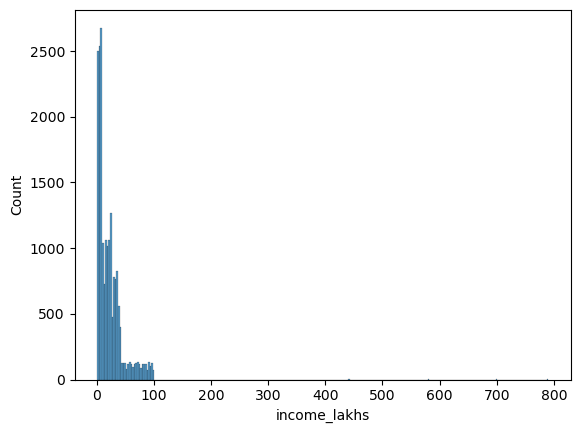

In [26]:
sns.histplot(df["income_lakhs"])

In [27]:
def get_iqr_boundary(col):
    q1 , q3 = col.quantile([0.25,0.75])
    IQR = q3-q1
    lower = q1 - 1.5*IQR
    upper = q3 + 1.5*IQR
    return lower , upper 

In [29]:
get_iqr_boundary(df.income_lakhs)

(-31.5, 68.5)

In [30]:
df[df.income_lakhs>55]["income_lakhs"].count()

np.int64(1850)

Since there are almost 5k people with more than Q3 income level we cant drop them. Lets just do trial and error and find the real outlier zone 

In [31]:
df.income_lakhs.quantile(0.95)

np.float64(75.0)

In [32]:
df[df.income_lakhs>77]["income_lakhs"].count()

np.int64(907)

This is also too much to call outliers 

In [33]:
df.income_lakhs.quantile(0.99)

np.float64(95.0)

In [34]:
df[df.income_lakhs>96]["income_lakhs"].count()

np.int64(161)

Still Cant drop 

In [36]:
df.income_lakhs.quantile(0.999)

np.float64(100.0)

In [37]:
df[df.income_lakhs>100]["income_lakhs"].count()

np.int64(4)

In [38]:
income_threshold = df.income_lakhs.quantile(0.999)

In [39]:
df_2 = df[df.income_lakhs<=income_threshold].copy()

df_2.describe()

,age,number_of_dependants,income_lakhs,annual_premium_amount,genetical_risk
count,20086.000000,20086.000000,20086.000000,20086.000000,20086.000000
mean,21.494474,0.722742,22.390371,8141.799263,2.503883
std,2.294248,0.937238,21.732062,2749.912486,1.710184
min,18.000000,0.000000,1.000000,3501.000000,0.000000
25%,19.000000,0.000000,6.000000,6022.000000,1.000000
50%,22.000000,0.000000,16.000000,7939.000000,3.000000
75%,23.000000,1.000000,31.000000,9561.000000,4.000000
max,25.000000,3.000000,100.000000,18186.000000,5.000000


In [40]:
df_2.shape

(20086, 14)

# Exploratory Data Analysis 

### Univariate Analysis

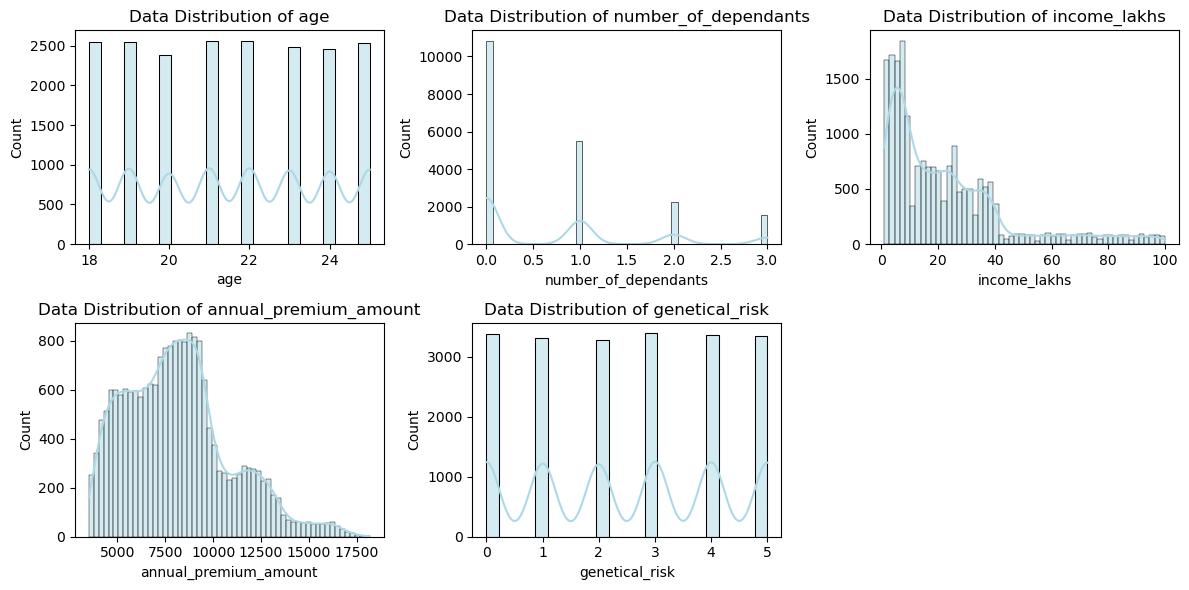

In [45]:
plt.figure(figsize=(12,6))

for i, col in enumerate(numerical_columns):
    plt.subplot(2, 3, i + 1)
    sns.histplot(x=df_2[col], color='lightblue', kde=True)
    plt.title(f"Data Distribution of {col}")

plt.tight_layout()
plt.show()

Finding all the Categorical columns 

In [48]:
categorical_cols = df.select_dtypes(exclude='number').columns

print(categorical_cols)

Index(['gender', 'region', 'marital_status', 'bmi_category', 'smoking_status',
       'employment_status', 'income_level', 'medical_history',
       'insurance_plan'],
      dtype='object')


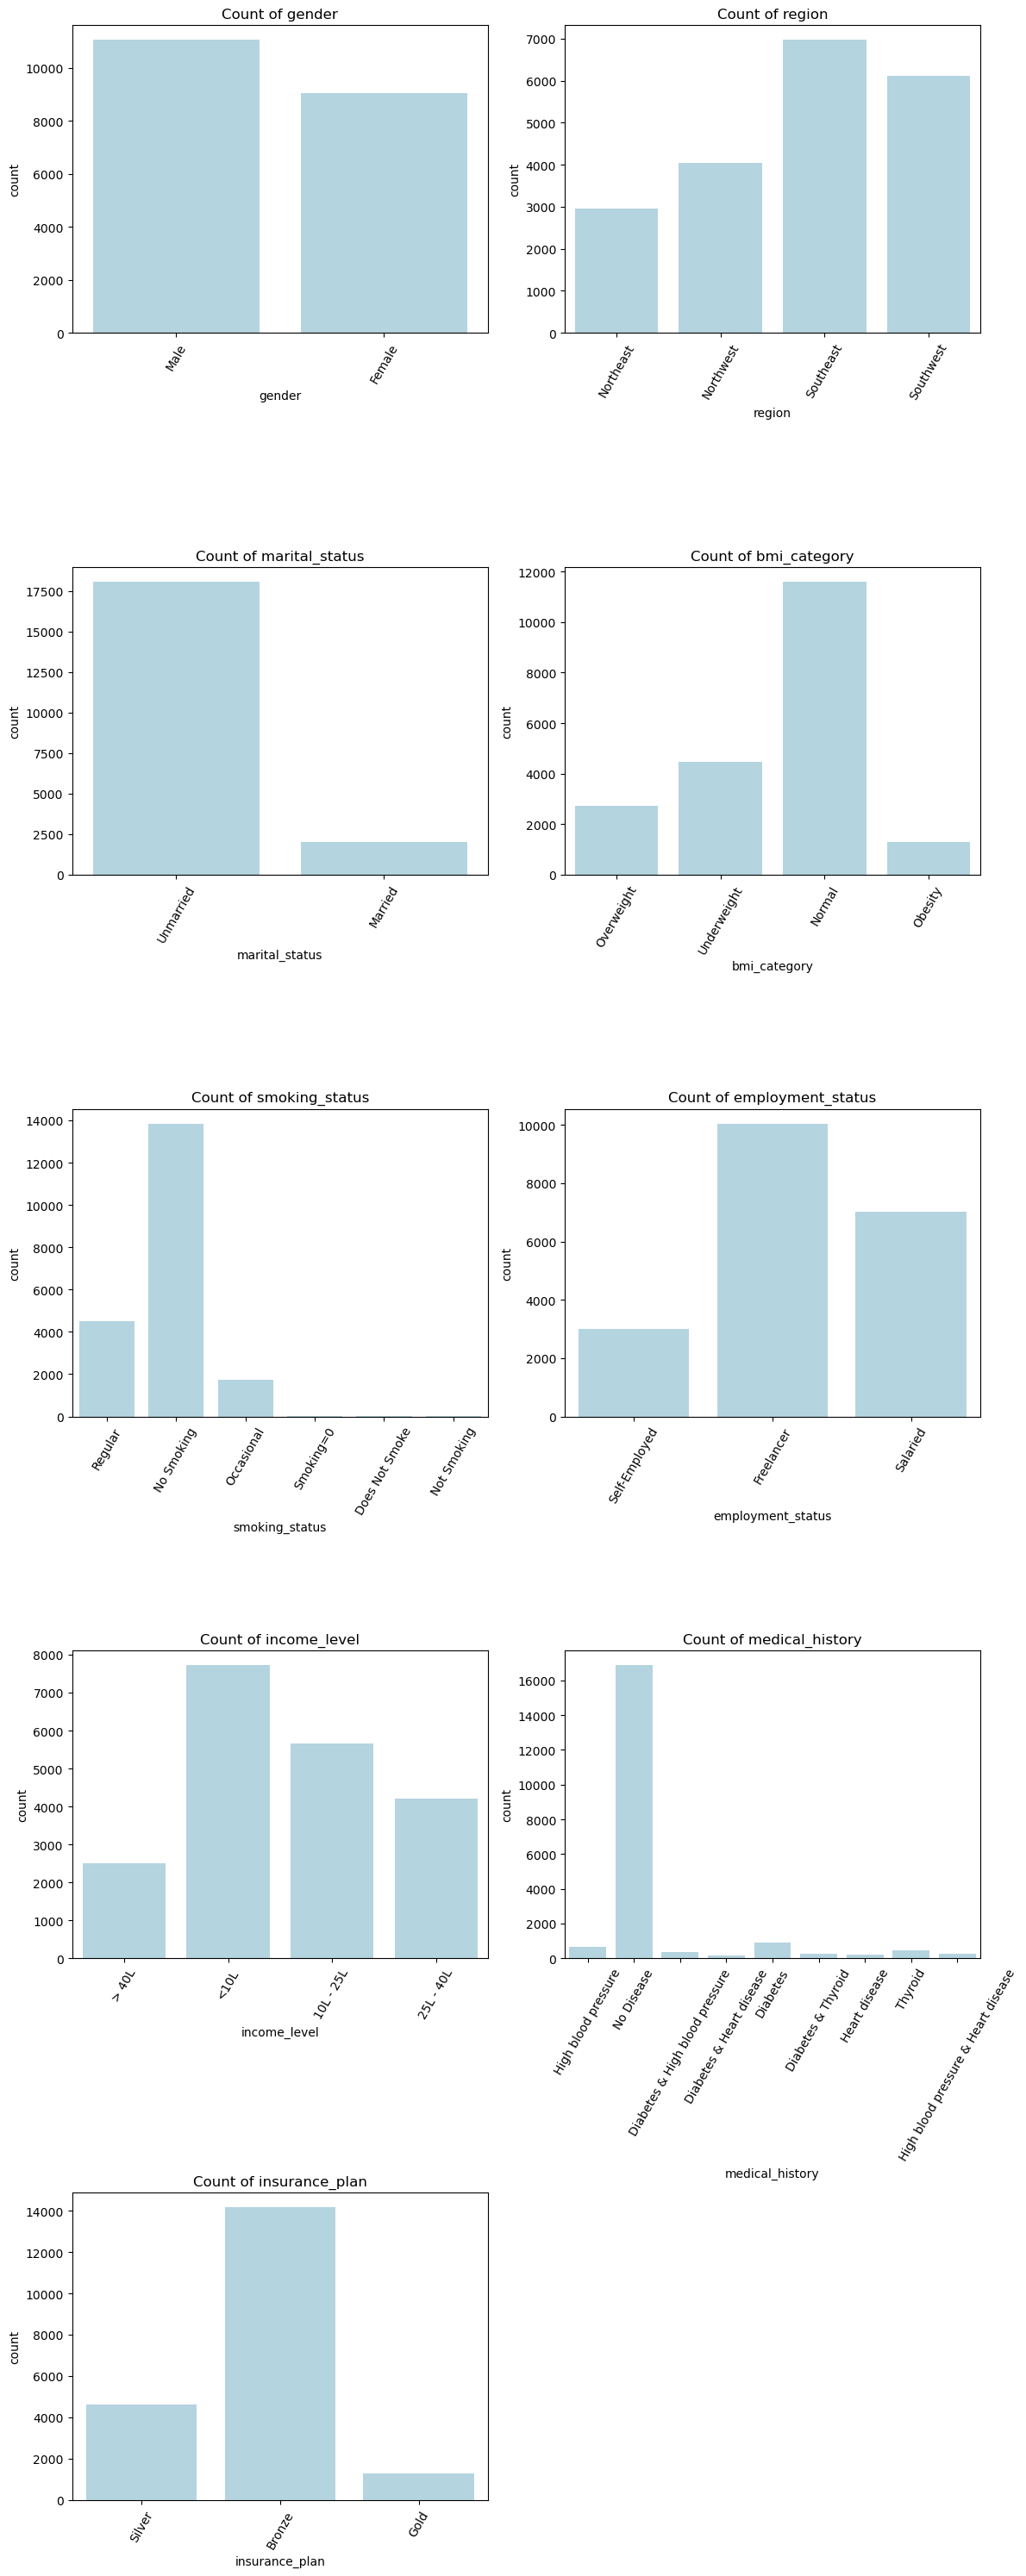

In [49]:
rows = (len(categorical_cols) + 1) // 2

plt.figure(figsize=(12, rows*6))

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, 2, i + 1)
    sns.countplot(x=df[col], color='lightblue')
    plt.title(f"Count of {col}")
    plt.xticks(rotation=60)
    plt.tight_layout()

plt.show()

In [52]:
for col in categorical_cols:
    print(f"{col} -- {df_2[col].unique()}\n")

gender -- ['Male' 'Female']

region -- ['Northeast' 'Northwest' 'Southeast' 'Southwest']

marital_status -- ['Unmarried' 'Married']

bmi_category -- ['Overweight' 'Underweight' 'Normal' 'Obesity']

smoking_status -- ['Regular' 'No Smoking' 'Occasional' 'Smoking=0' 'Does Not Smoke'
 'Not Smoking']

employment_status -- ['Self-Employed' 'Freelancer' 'Salaried']

income_level -- ['> 40L' '<10L' '10L - 25L' '25L - 40L']

medical_history -- ['High blood pressure' 'No Disease' 'Diabetes & High blood pressure'
 'Diabetes & Heart disease' 'Diabetes' 'Diabetes & Thyroid'
 'Heart disease' 'Thyroid' 'High blood pressure & Heart disease']

insurance_plan -- ['Silver' 'Bronze' 'Gold']



Inside Smoking column there are values ( Smoking=0,Doesn not smoke and not smoking) Which all means Not smoking

In [53]:
df_2["smoking_status"] = df_2["smoking_status"].replace({

    "Smoking=0" : "No Smoking", 
    "Does Not Smoke" : "No Smoking", 
    "Not Smoking" : "No Smoking"
    })

df_2["smoking_status"].unique()

array(['Regular', 'No Smoking', 'Occasional'], dtype=object)

### Bivariate Analysis

In [54]:
numerical_features = ["age","income_lakhs","number_of_dependants"]

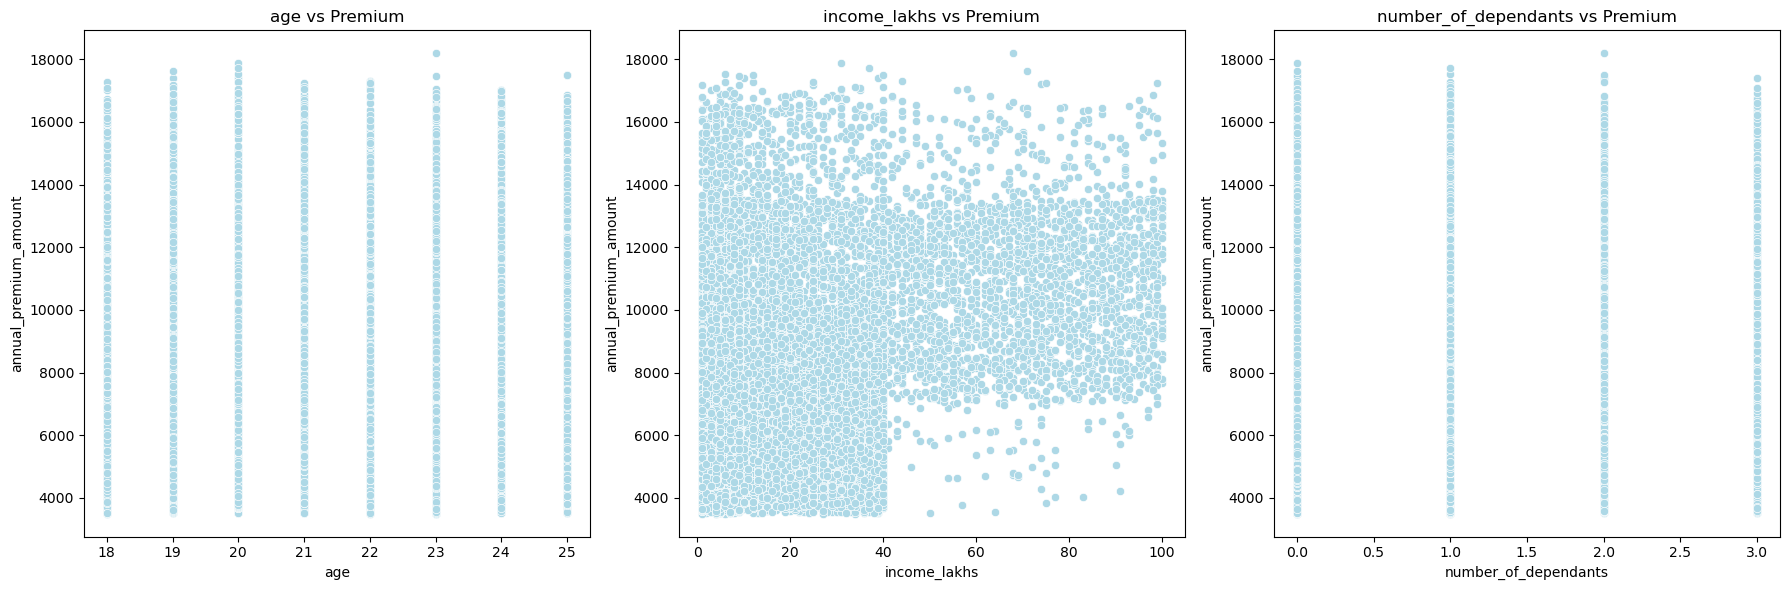

In [55]:
plt.figure(figsize=(18, 6)) 

for i, col in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1)
    sns.scatterplot(data=df_2, x=col, y="annual_premium_amount", color='lightblue')
    plt.title(f"{col} vs Premium")

plt.tight_layout()
plt.show()

### Barplot ( Percentage Share of Premium vs Catergorical Data )

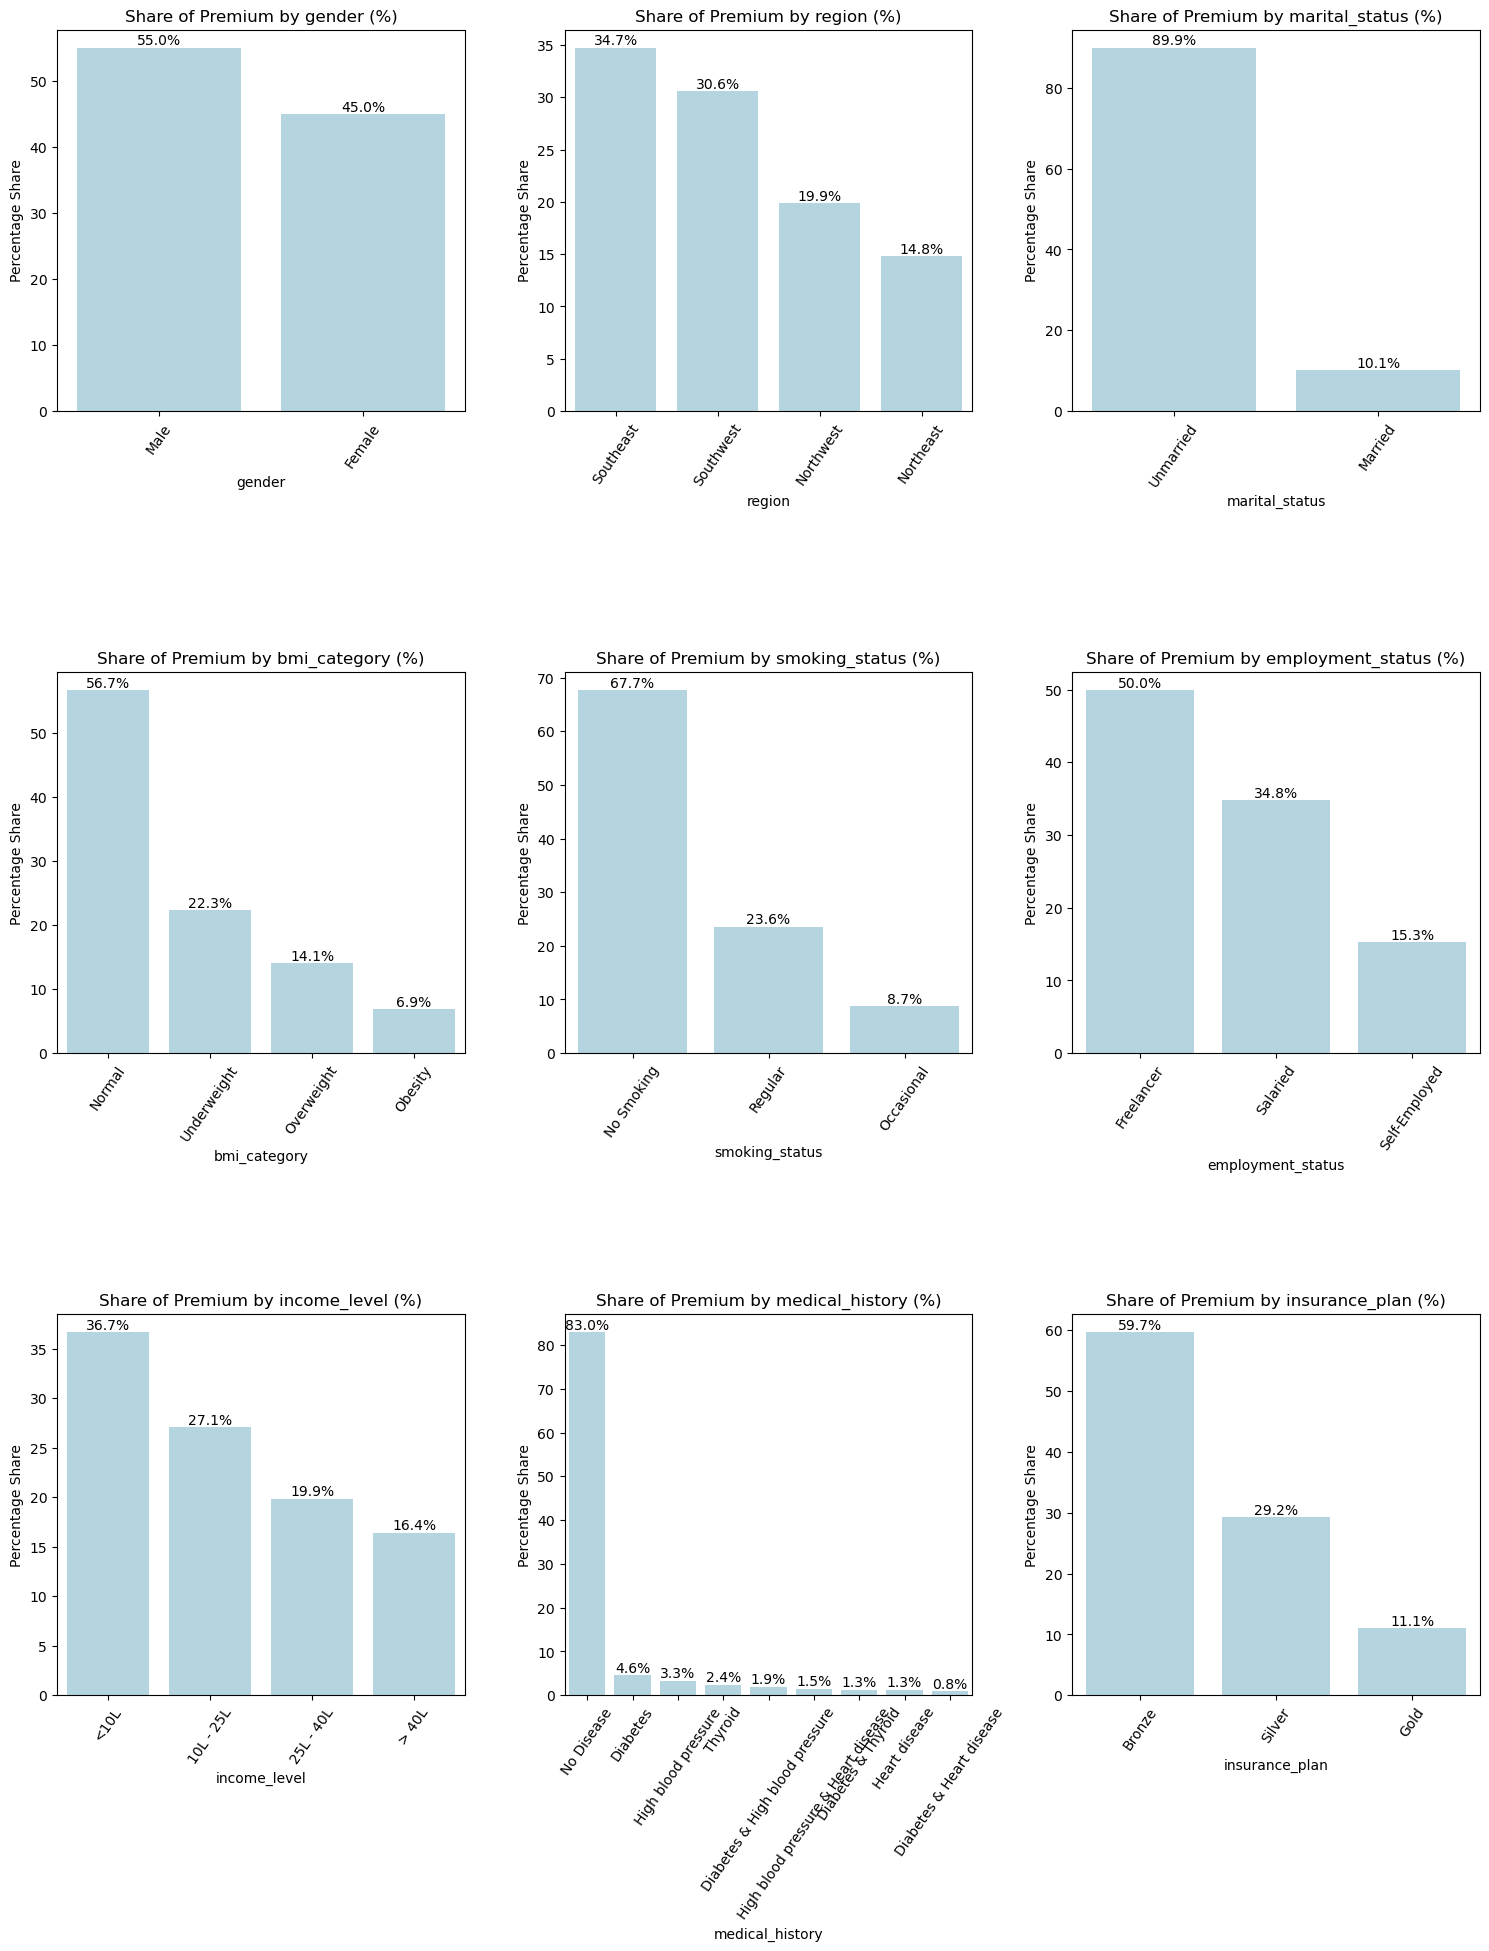

In [56]:
rows = (len(categorical_cols) + 1) // 2 
plt.figure(figsize=(15, rows * 6))

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, 3, i + 1)
    
    group_sum = df_2.groupby(col)["annual_premium_amount"].sum()
    percent_data = (group_sum / group_sum.sum()) * 100
    
    percent_data = percent_data.sort_values(ascending=False)
    
    ax = sns.barplot(x=percent_data.index, y=percent_data.values, color='lightblue')

    plt.title(f"Share of Premium by {col} (%)")
    plt.ylabel("Percentage Share")
    plt.xticks(rotation=55)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%')

plt.tight_layout()
plt.show()

### Average Premium vs Categories

Most important as it will help me at the time of Feature Engineering to assign the Odinal values in label encoding 

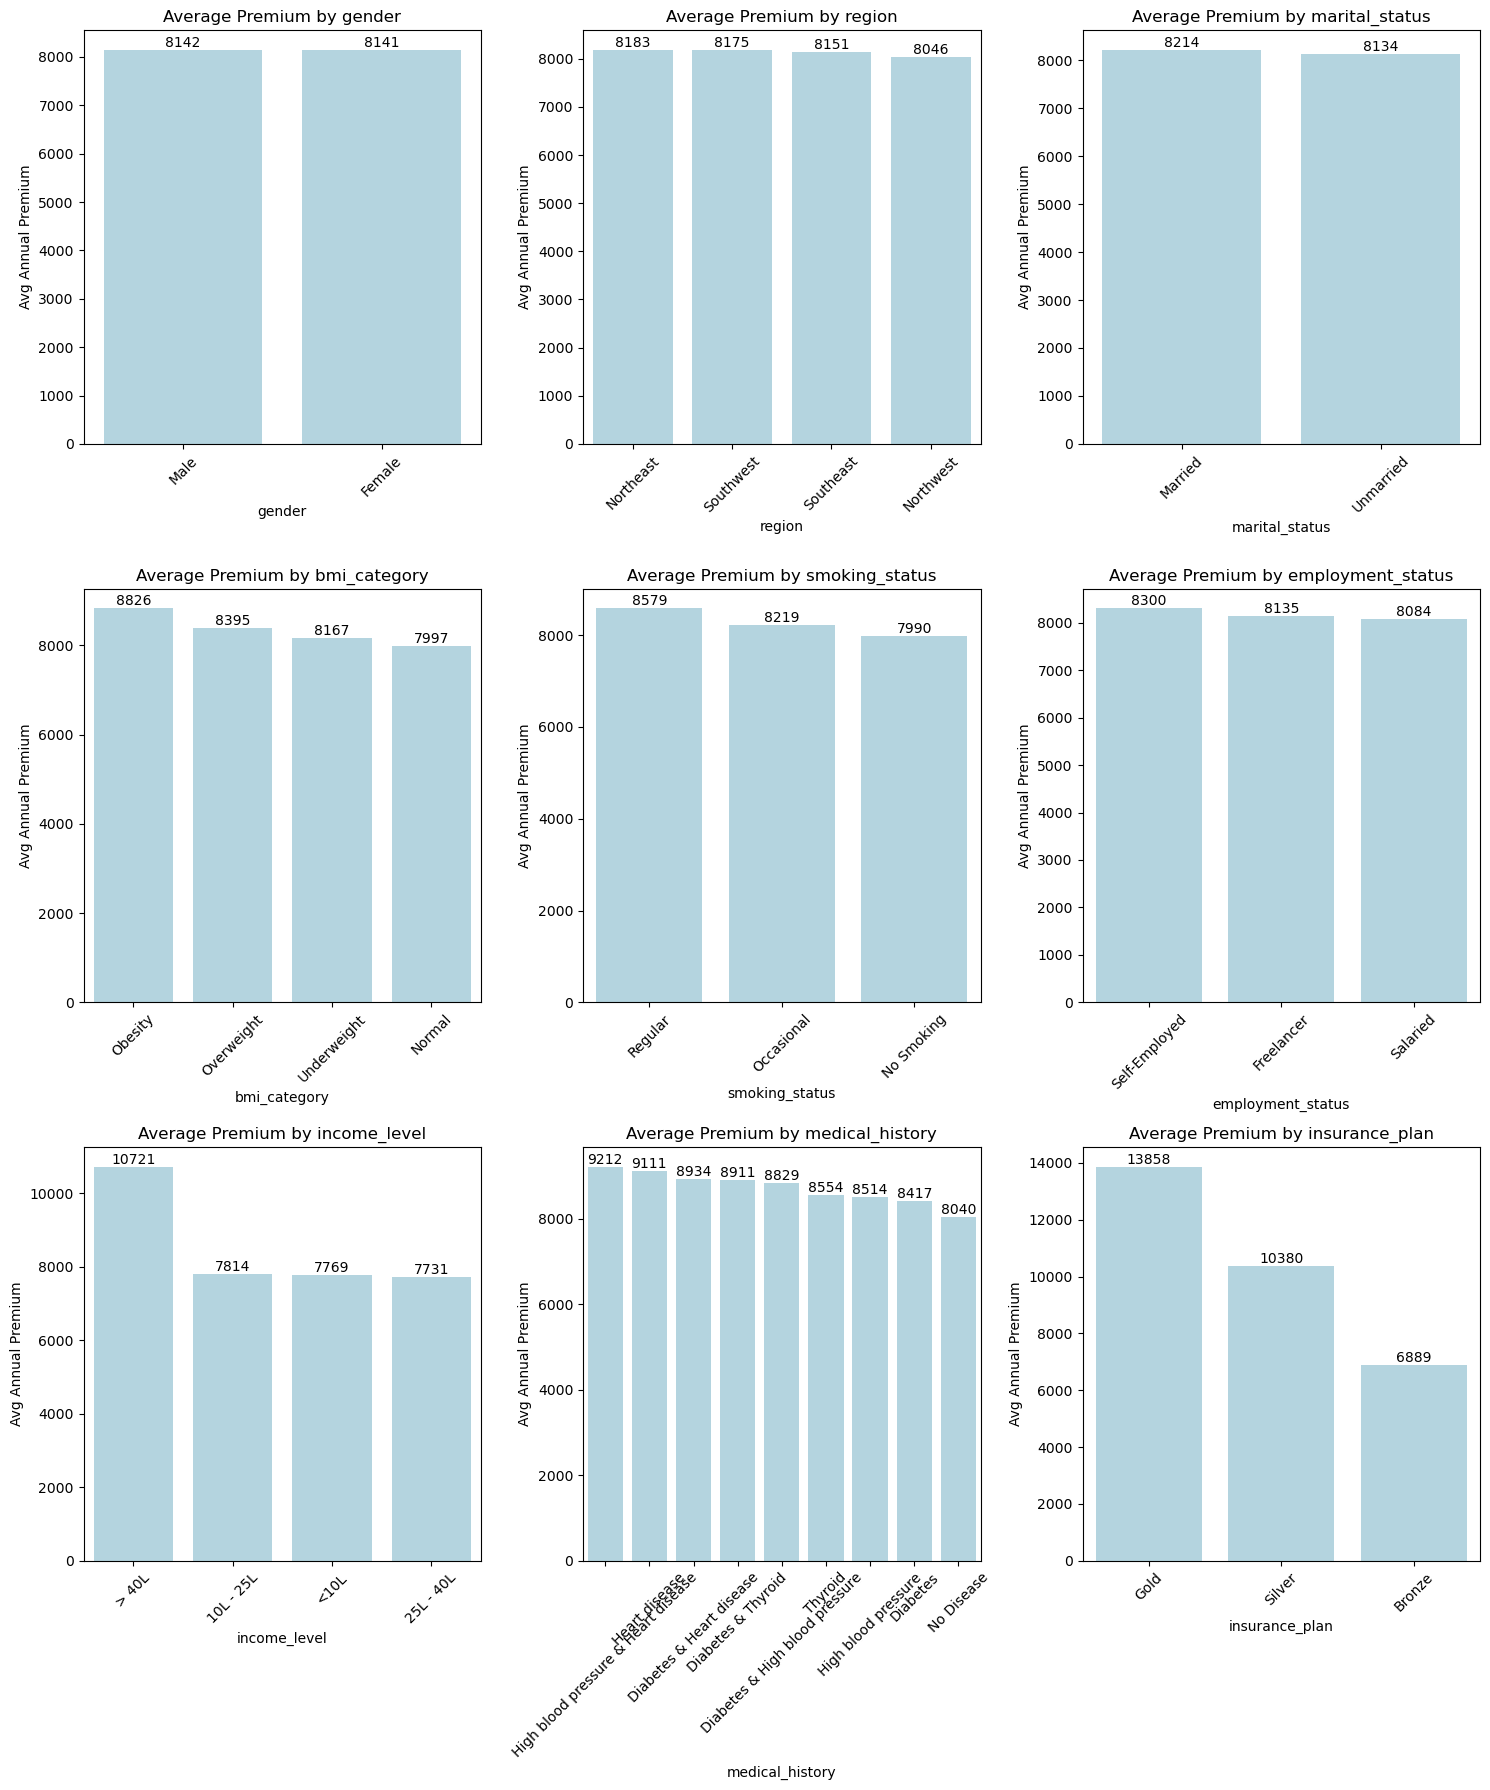

In [57]:
rows = (len(categorical_cols) + 2) // 3 

plt.figure(figsize=(15, rows * 6))

for i, col in enumerate(categorical_cols):
    plt.subplot(rows, 3, i + 1)
    avg_data = df_2.groupby(col)["annual_premium_amount"].mean()
    avg_data = avg_data.sort_values(ascending=False)
    
    ax = sns.barplot(x=avg_data.index, y=avg_data.values, color='lightblue')

    plt.title(f"Average Premium by {col}")
    plt.ylabel("Avg Annual Premium")
    plt.xticks(rotation=45)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f')

plt.tight_layout()
plt.show()


### Employment Status vs Plan Preference

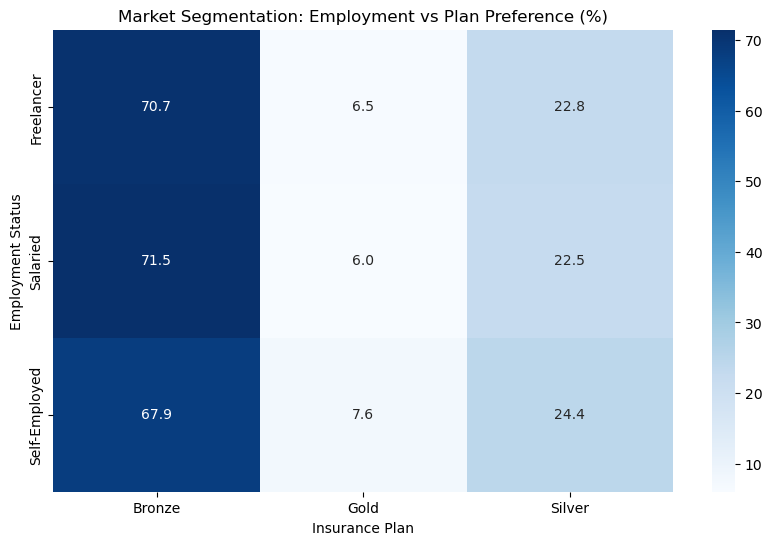

In [58]:
cross_tab_prop = pd.crosstab(df_2['employment_status'], df_2['insurance_plan'], normalize='index') * 100

plt.figure(figsize=(10, 6))
sns.heatmap(cross_tab_prop, annot=True, fmt='.1f', cmap='Blues')
plt.title("Market Segmentation: Employment vs Plan Preference (%)")
plt.ylabel("Employment Status")
plt.xlabel("Insurance Plan")
plt.show()


### Average Premium: Gender vs Smoker Status

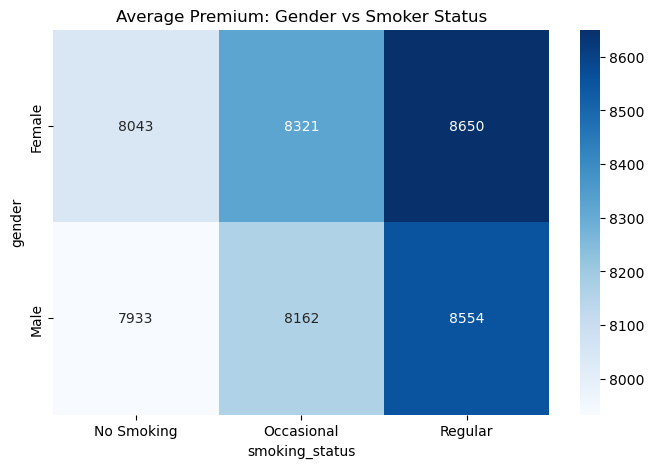

In [59]:
premium_matrix = pd.crosstab(
    index=df_2['gender'], 
    columns=df_2['smoking_status'], 
    values=df_2['annual_premium_amount'], 
    aggfunc='mean'
)

plt.figure(figsize=(8, 5))
sns.heatmap(premium_matrix, annot=True, fmt='.0f', cmap='Blues')
plt.title("Average Premium: Gender vs Smoker Status")
plt.show()


### Average Annual Premium: Smoking vs Medical History

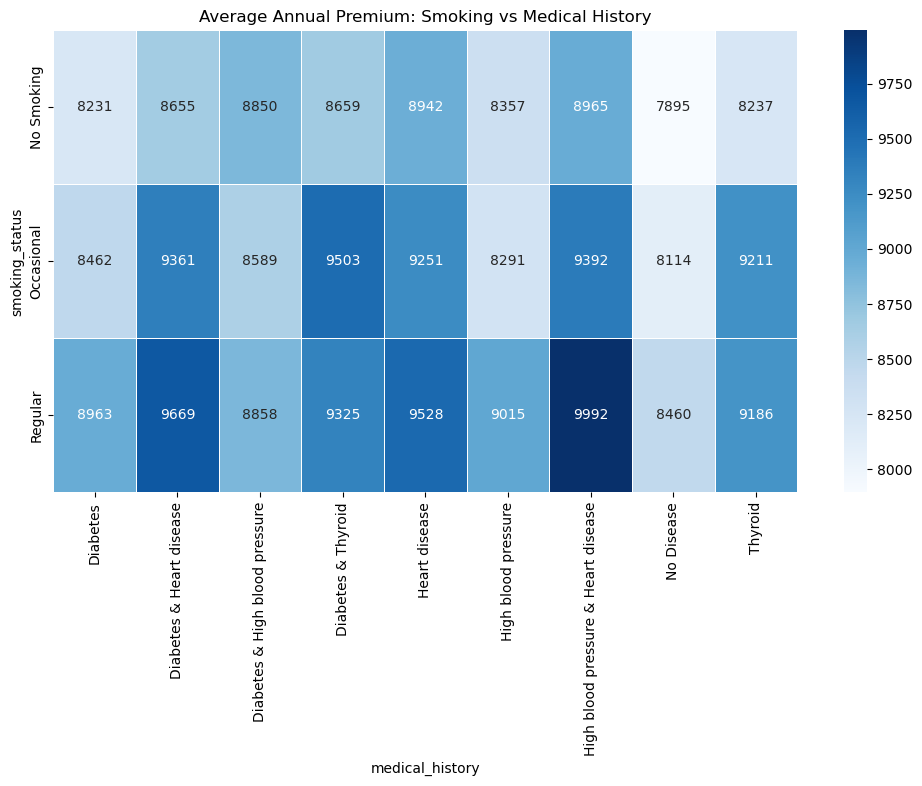

In [62]:
risk_matrix = pd.crosstab(
    index=df_2['smoking_status'], 
    columns=df_2['medical_history'], 
    values=df_2['annual_premium_amount'], 
    aggfunc='mean'
)
plt.figure(figsize=(12, 6))
sns.heatmap(risk_matrix, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)

plt.title("Average Annual Premium: Smoking vs Medical History")
plt.show()


### Average Premium - Genetical Risk Vs Medical History

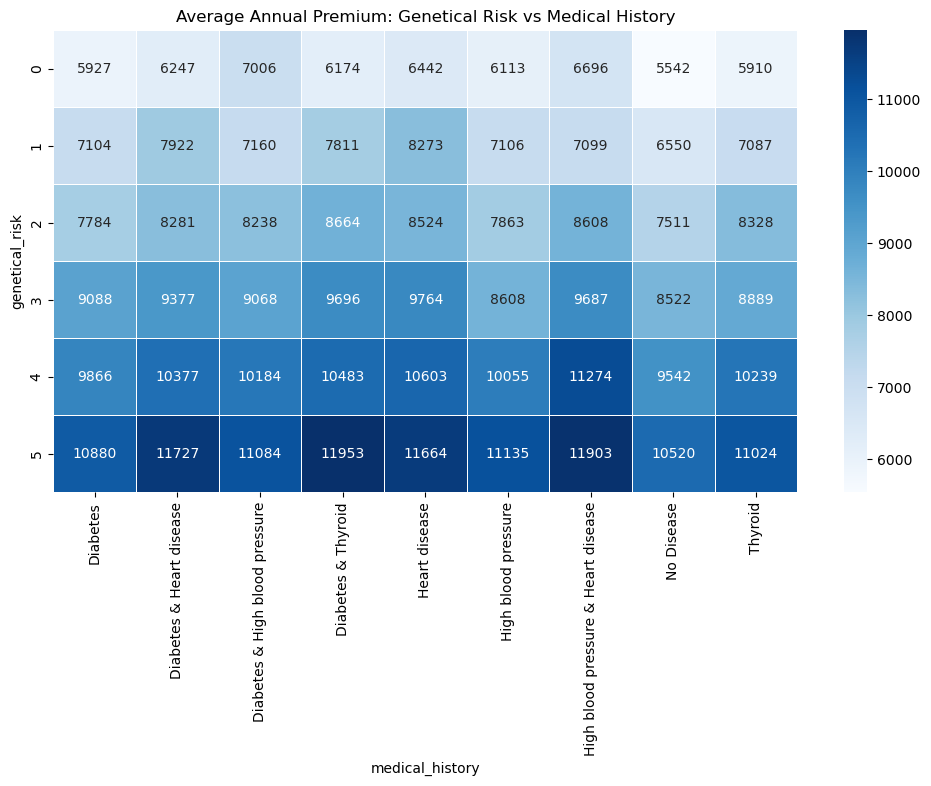

In [65]:
risk_matrix = pd.crosstab(
    index=df_2['genetical_risk'], 
    columns=df_2['medical_history'], 
    values=df_2['annual_premium_amount'], 
    aggfunc='mean'
)
plt.figure(figsize=(12, 6))
sns.heatmap(risk_matrix, annot=True, fmt='.0f', cmap='Blues', linewidths=0.5)

plt.title("Average Annual Premium: Genetical Risk vs Medical History")
plt.show()


### Income vs Insurance Plan

In [66]:
crosstab = pd.crosstab(df_2["income_level"],df_2["insurance_plan"])
print(crosstab)

insurance_plan  Bronze  Gold  Silver
income_level                        
10L - 25L         4508   326     828
25L - 40L         3382   209     608
<10L              6172   404    1145
> 40L              115   366    2023


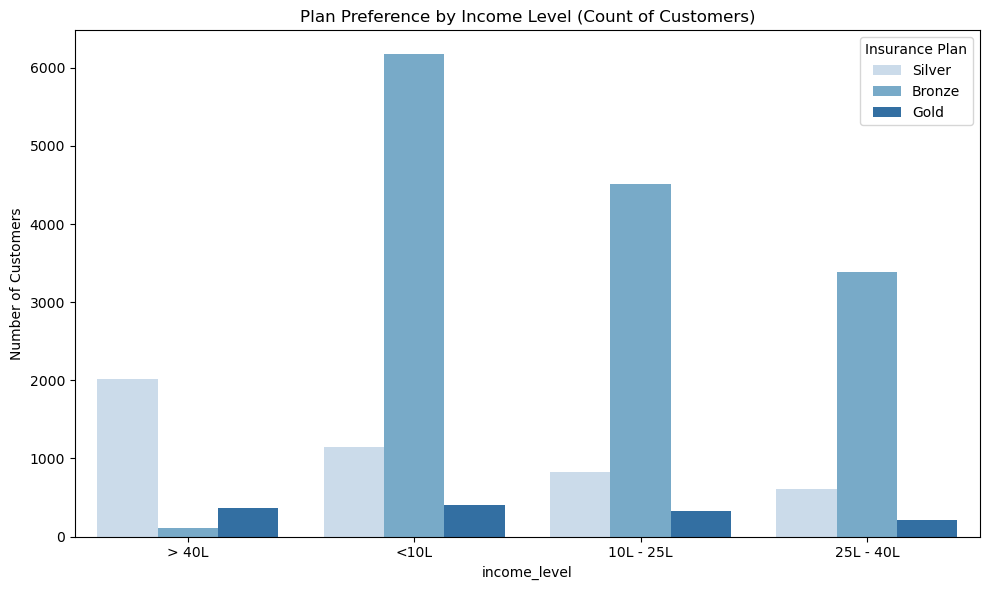

In [101]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df_2, 
    x="income_level", 
    hue="insurance_plan", 
    palette="Blues"
)

plt.title("Plan Preference by Income Level (Count of Customers)")
plt.ylabel("Number of Customers")
plt.legend(title="Insurance Plan")

plt.tight_layout()
plt.show()


### Average Premium by Income and Insurance Plan

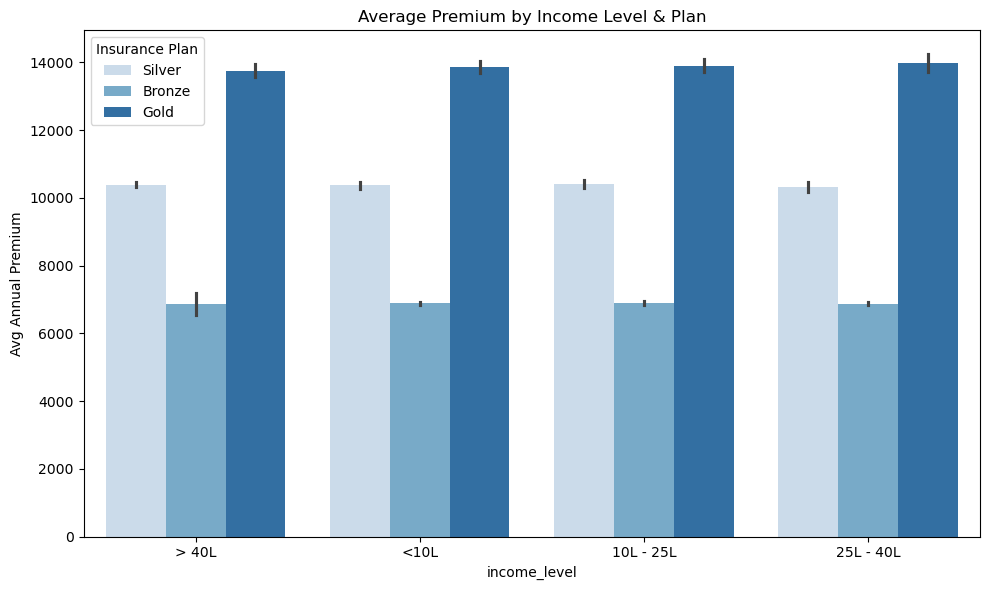

In [102]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=df_2, 
    x="income_level", 
    y="annual_premium_amount", 
    hue="insurance_plan", 
    palette="Blues"
)

plt.title("Average Premium by Income Level & Plan")
plt.ylabel("Avg Annual Premium")
plt.legend(title="Insurance Plan")

plt.tight_layout()
plt.show()


### Age vs Average Premium

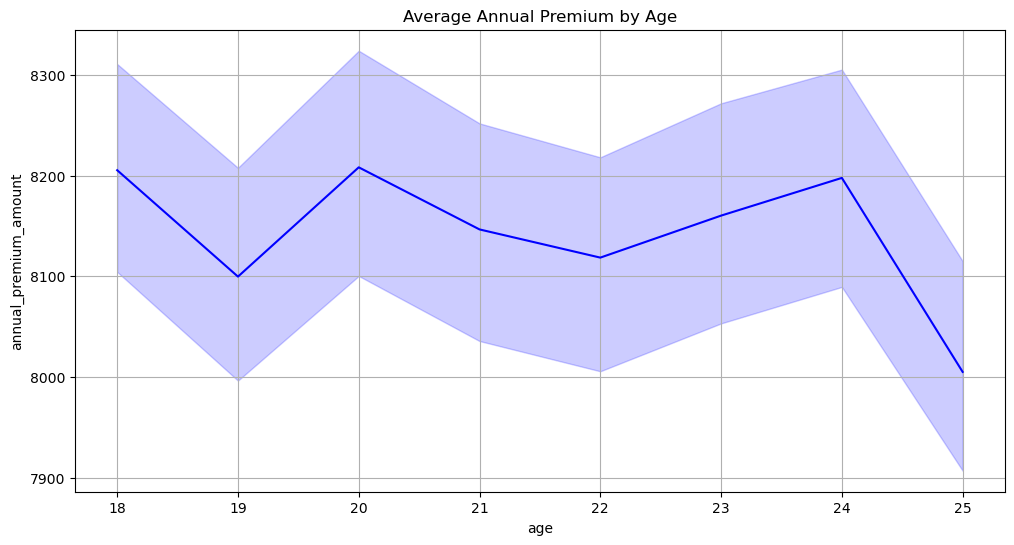

In [103]:
plt.figure(figsize=(12, 6))

sns.lineplot(data=df_2, x="age", y="annual_premium_amount", color='blue')

plt.title("Average Annual Premium by Age")
plt.grid()
plt.show()

### Employment Status Vs Avg Premium 

employment_status
Salaried         8084.400370
Freelancer       8134.592154
Self-Employed    8299.818061
Name: annual_premium_amount, dtype: float64


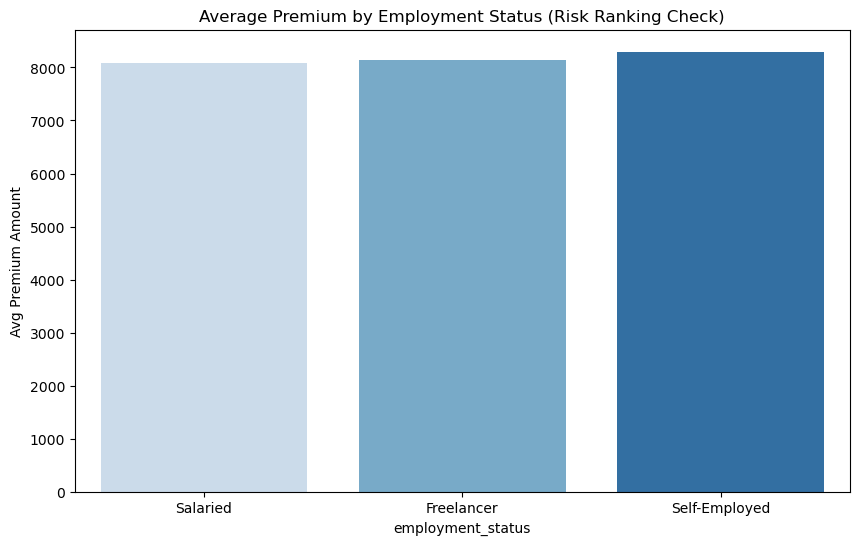

In [104]:
job_price = df_2.groupby('employment_status')['annual_premium_amount'].mean().sort_values()

print(job_price)

plt.figure(figsize=(10, 6))
sns.barplot(x=job_price.index, y=job_price.values,hue=job_price.index,palette="Blues")

plt.title("Average Premium by Employment Status (Risk Ranking Check)")
plt.ylabel("Avg Premium Amount")
plt.show()

### Genetical Risk vs Avg Premium

genetical_risk
0     5657.538507
1     6660.279807
2     7611.285888
3     8622.650766
4     9641.636499
5    10633.837910
Name: annual_premium_amount, dtype: float64


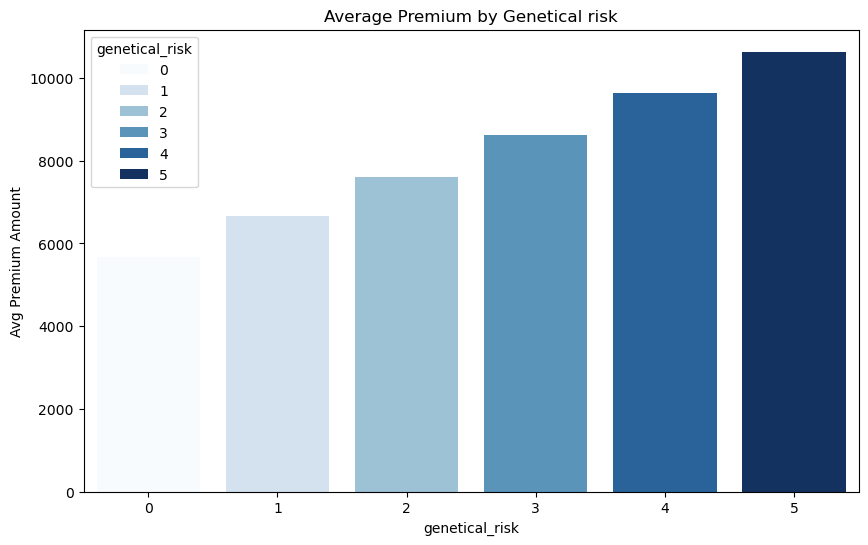

In [105]:
genetics_price = df_2.groupby('genetical_risk')['annual_premium_amount'].mean().sort_values()

print(genetics_price)

plt.figure(figsize=(10, 6))
sns.barplot(x=genetics_price.index, y=genetics_price.values,hue=genetics_price.index,palette="Blues")

plt.title("Average Premium by Genetical risk")
plt.ylabel("Avg Premium Amount")
plt.show()

### Saving the Clean Dataset

In [106]:
df_2.to_csv("premium_youth_clean.csv", index=False)

# Feature Engineering

In [107]:
df_cleaned = pd.read_csv("pluse_healthcare_clean.csv")

df.head()

,age,gender,region,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_level,income_lakhs,medical_history,insurance_plan,annual_premium_amount,genetical_risk
0,18,Male,Northeast,Unmarried,0,Overweight,Regular,Self-Employed,> 40L,99,High blood pressure,Silver,13365,4
1,22,Female,Northwest,Unmarried,0,Underweight,No Smoking,Freelancer,<10L,3,No Disease,Silver,11050,3
2,21,Female,Southeast,Unmarried,0,Normal,Regular,Salaried,> 40L,97,No Disease,Silver,11857,4
3,25,Male,Southeast,Unmarried,0,Normal,No Smoking,Freelancer,10L - 25L,15,No Disease,Bronze,5684,2
4,20,Male,Southeast,Unmarried,2,Overweight,No Smoking,Freelancer,10L - 25L,14,No Disease,Bronze,5712,1


In [108]:
df_cleaned.shape

(20086, 14)

In [109]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20086 entries, 0 to 20085
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype 
---  ------                 --------------  ----- 
 0   age                    20086 non-null  int64 
 1   gender                 20086 non-null  object
 2   region                 20086 non-null  object
 3   marital_status         20086 non-null  object
 4   number_of_dependants   20086 non-null  int64 
 5   bmi_category           20086 non-null  object
 6   smoking_status         20086 non-null  object
 7   employment_status      20086 non-null  object
 8   income_level           20086 non-null  object
 9   income_lakhs           20086 non-null  int64 
 10  medical_history        20086 non-null  object
 11  insurance_plan         20086 non-null  object
 12  annual_premium_amount  20086 non-null  int64 
 13  genetical_risk         20086 non-null  int64 
dtypes: int64(5), object(9)
memory usage: 2.1+ MB


In [110]:
df_cleaned["income_level"].value_counts()

income_level
<10L         7721
10L - 25L    5662
25L - 40L    4199
> 40L        2504
Name: count, dtype: int64

Since we already have the exact income salary so actually we dont need income_level . it will increase the multicollinearinty and also increace the dimentionality which is not a good thing

In [111]:
df_cleaned = df_cleaned.drop(columns="income_level")

Since our income was found to be Rightly Skewed hence lets normalize it 

In [112]:
df_cleaned["income_log"] = np.log1p(df_cleaned["income_lakhs"])

df_cleaned["income_log"].describe()

count    20086.000000
mean         2.722688
std          0.978709
min          0.693147
25%          1.945910
50%          2.833213
75%          3.465736
max          4.615121
Name: income_log, dtype: float64

Per Capita Income of the family ( 1 + dependants )

In [113]:
df_cleaned["per_capita_income"] = df_cleaned["income_lakhs"]/(df_cleaned["number_of_dependants"] + 1)

### OneHot Encoding for Nominal categories

In [114]:
df_cleaned = pd.get_dummies(df_cleaned,columns=["gender", "region"],drop_first=True,dtype=int)

### TRAIN TEST SPLIT 

In [115]:
from sklearn.model_selection import train_test_split

X = df_cleaned.drop(columns=["annual_premium_amount"])
y = df_cleaned["annual_premium_amount"]

Train Test Split ( we are splitting the data into Training and testing sets)

In [116]:
X_train , X_test , y_train , y_test =train_test_split(X,y,test_size=0.2,random_state=42)

Making Training_data column to now calculate all the Target Mean Encoding without leaking the data

In [117]:
training_data = X_train.copy()
training_data["annual_premium_amount"] = y_train

Now that we have splitted the X and y we can do the Target Means Encoding and Odinal Encoding Seperately to prevent data Leakag

### Odinal Encoding ( Based on order of priority )

Doing the One Hot encoding based ont the priority found in my EDA 

In [118]:
X_train['insurance_plan'] = X_train['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})
X_test['insurance_plan'] = X_test['insurance_plan'].map({'Bronze': 1, 'Silver': 2, 'Gold': 3})


X_train['employment_status'] = X_train['employment_status'].map({'Freelancer': 1, 'Salaried': 2, 'Self-Employed': 3})
X_test['employment_status'] = X_test['employment_status'].map({'Freelancer': 1, 'Salaried': 2, 'Self-Employed': 3})

### Target Mean Encoding

Based on observation in EDA. Few columnbs have non linear Odinal relation with Annual Preiumn 

That is why im using groupby average premium for those target Columns

In [119]:
target_cols = ['medical_history', 'bmi_category', 'marital_status', 'smoking_status']
global_mean_premium = y_train.mean()

for col in target_cols:
    mean_dict = training_data.groupby(col)['annual_premium_amount'].mean().to_dict()
    
    X_train[col] = X_train[col].map(mean_dict)
    
    X_test[col] = X_test[col].map(mean_dict)
    X_test[col] = X_test[col].fillna(global_mean_premium)

### FEATURE CREATION 

Based on EDA and the Domain knowledge i have created few new features ( if they will be helpful then i will keep it else i will drop it )

In [120]:
def feature_creation(data):
    data["risk_smoke"] = data['age'] * data['smoking_status']
    
    raw_health = data["bmi_category"] * data['medical_history'] * data["smoking_status"]
    data["health_risk_score"] = np.log1p(raw_health)
    
    raw_weighted = data["age"] * data["health_risk_score"]
    data["weighted_risk_score"] = np.log1p(raw_weighted)
    
    return data

X_train = feature_creation(X_train)
X_test = feature_creation(X_test)

In [121]:
X_train.head()

,age,marital_status,number_of_dependants,bmi_category,smoking_status,employment_status,income_lakhs,medical_history,insurance_plan,genetical_risk,income_log,per_capita_income,gender_Male,region_Northwest,region_Southeast,region_Southwest,risk_smoke,health_risk_score,weighted_risk_score
15288,18,8133.728309,0,7981.847866,8585.180665,1,7,8036.439698,3,3,2.079442,7.000000,1,0,0,0,154533.251973,27.034459,6.189537
14734,25,8133.728309,2,8177.298937,7981.986224,1,14,8036.439698,1,3,2.708050,4.666667,0,0,1,0,199549.655592,26.985801,6.515668
2893,24,8133.728309,2,7981.847866,7981.986224,2,9,8036.439698,1,1,2.302585,3.000000,0,0,0,1,191567.669368,26.961609,6.474012
2608,25,8133.728309,1,7981.847866,7981.986224,2,15,8036.439698,1,1,2.772589,7.500000,1,0,0,1,199549.655592,26.961609,6.514772
13959,24,8133.728309,1,8177.298937,7981.986224,1,5,8036.439698,1,0,1.791759,2.500000,1,0,0,1,191567.669368,26.985801,6.474908


In [122]:
X_test.shape

(4018, 19)

In [123]:
X_train.shape

(16068, 19)

### Scaling and Baseline model

In [124]:
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error , r2_score

Selecting Columns that need Scaling ( excluding the OHE Encoded colums )

In [125]:
scaling_cols = [
    'age', 'number_of_dependants', 'income_lakhs', 'per_capita_income', 
    'medical_history', 'bmi_category', 'marital_status', 'smoking_status',
    'risk_smoke', 'health_risk_score', 'weighted_risk_score'
]

scaler = StandardScaler()

X_train[scaling_cols] = scaler.fit_transform(X_train[scaling_cols])
X_test[scaling_cols] = scaler.transform(X_test[scaling_cols])

### Baseline Model ( Random FOrest )

In [126]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
training_score = rf_base.score(X_train,y_train)
testing_score = rf_base.score(X_test,y_test)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R2: {r2:,.2f}")
print(f"Training Score for the baseline model is : {training_score:,.2f}")
print(f"Testing Score for the baseline model is : {testing_score:,.2f}")


Mean Absolute Error (MAE): 268.44
Root Mean Squared Error (RMSE): 316.29
R2: 0.99
Training Score for the baseline model is : 1.00
Testing Score for the baseline model is : 0.99


### Feature Importance of Baseline model - Randomforest 


In [127]:
importance = rf_base.feature_importances_
feature_names= X_train.columns

impt_feature_df = pd.DataFrame({"features":feature_names , "importance" : importance}).sort_values(by="importance",ascending=False)

impt_feature_df

,features,importance
8,insurance_plan,0.581918
9,genetical_risk,0.382843
17,health_risk_score,0.024570
11,per_capita_income,0.002193
10,income_log,0.001218
6,income_lakhs,0.001211
18,weighted_risk_score,0.001064
16,risk_smoke,0.000795
5,employment_status,0.000775
0,age,0.000554


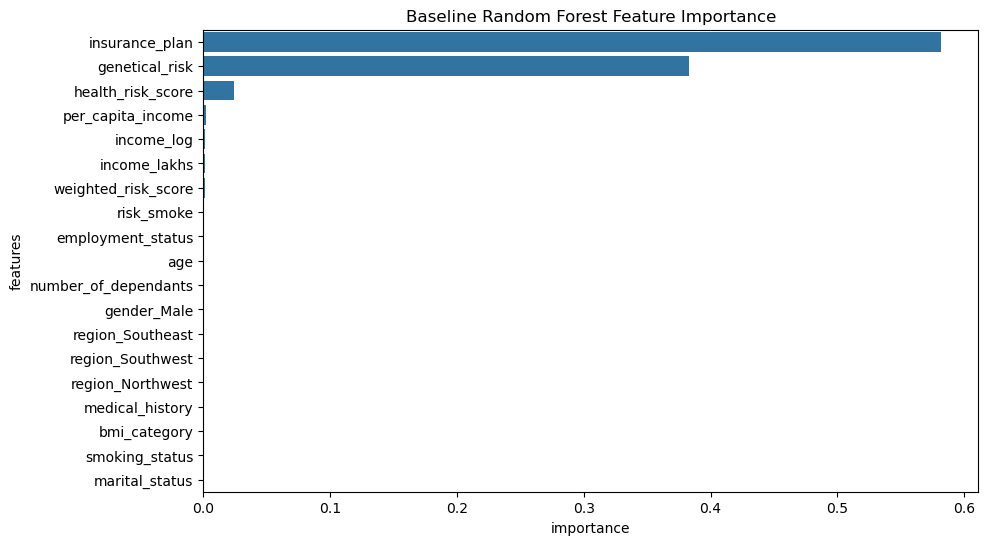

In [128]:
plt.figure(figsize=(10, 6))
sns.barplot(data=impt_feature_df,x='importance', y='features')
plt.title('Baseline Random Forest Feature Importance')
plt.show()

### Checking Coreelation Matrix

In [129]:
X_train.columns

Index(['age', 'marital_status', 'number_of_dependants', 'bmi_category',
       'smoking_status', 'employment_status', 'income_lakhs',
       'medical_history', 'insurance_plan', 'genetical_risk', 'income_log',
       'per_capita_income', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'risk_smoke',
       'health_risk_score', 'weighted_risk_score'],
      dtype='object')

In [130]:
cm_matrix_df = X_train.copy()

cm_matrix_df["annual_premium_price"] = y_train

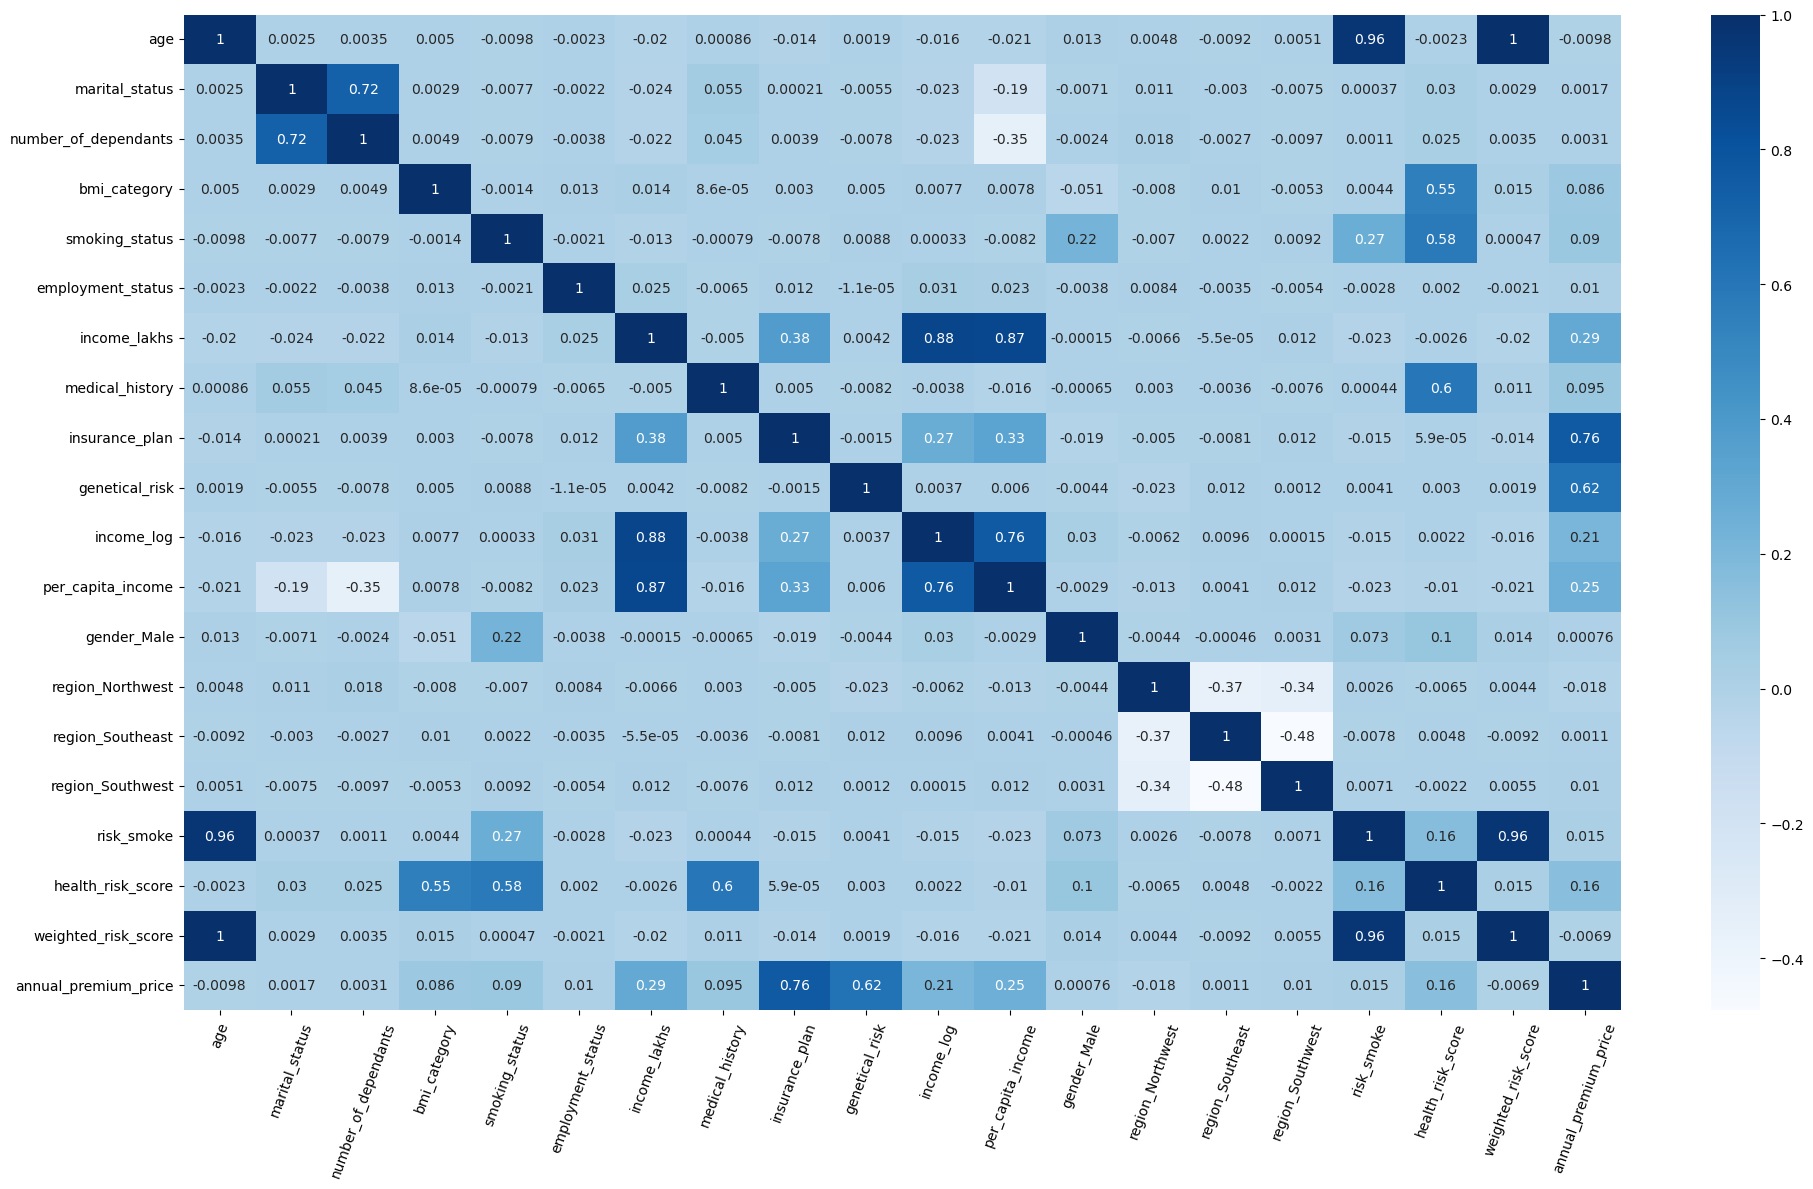

In [131]:
cm = cm_matrix_df.corr()

plt.figure(figsize=(20,12))
sns.heatmap(cm,annot=True,cmap="Blues")
plt.xticks(rotation=70)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### VIF Score For Checking Multi-collinearity 

In [132]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [133]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["features"] = data.columns
    vif_df["vif_score"] = [variance_inflation_factor(data.values,i) for i in range (data.shape[1])]
    return vif_df.sort_values(by="vif_score",ascending=False)

calculate_vif(X_train)

,features,vif_score
17,health_risk_score,3891.863438
0,age,1511.459322
4,smoking_status,1405.783566
7,medical_history,1387.139768
3,bmi_category,1181.622457
16,risk_smoke,1158.022581
18,weighted_risk_score,452.856242
10,income_log,14.274937
6,income_lakhs,8.069394
11,per_capita_income,7.944167


Now based on the FEATURE IMPORTANCE , Correlation and VIF ( multi- collianarity ). We will Drop the Features that are not soo useful and cause the multicollinearity 

### Feature Selection ( Pruining )

In [134]:
columns_to_drop = ["income_lakhs","medical_history","bmi_category","health_risk_score"]

X_train = X_train.drop(columns=columns_to_drop)
X_test = X_test.drop(columns=columns_to_drop)

In [135]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["features"] = data.columns
    vif_df["vif_score"] = [variance_inflation_factor(data.values,i) for i in range (data.shape[1])]
    return vif_df.sort_values(by="vif_score",ascending=False)

calculate_vif(X_train)

,features,vif_score
0,age,1475.879037
13,risk_smoke,1157.520840
14,weighted_risk_score,414.881940
3,smoking_status,88.898850
7,income_log,12.424533
5,insurance_plan,5.945852
4,employment_status,5.475269
6,genetical_risk,2.987278
11,region_Southeast,2.935874
12,region_Southwest,2.716591


### Re-Training the Baseline model - Random Forest to check the new list of important features

In [136]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
training_score = rf_base.score(X_train,y_train)
testing_score = rf_base.score(X_test,y_test)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R2: {r2:,.2f}")
print(f"Training Score for the baseline model is : {training_score:,.2f}")
print(f"Testing Score for the baseline model is : {testing_score:,.2f}")


Mean Absolute Error (MAE): 300.43
Root Mean Squared Error (RMSE): 368.51
R2: 0.98
Training Score for the baseline model is : 1.00
Testing Score for the baseline model is : 0.98


### Retrained baseline model - Feature Importance List 

In [137]:
importance = rf_base.feature_importances_
feature_names= X_train.columns

impt_feature_df = pd.DataFrame({"features":feature_names , "importance" : importance}).sort_values(by="importance",ascending=False)

impt_feature_df

,features,importance
5,insurance_plan,0.581918
6,genetical_risk,0.382843
14,weighted_risk_score,0.011169
3,smoking_status,0.008316
8,per_capita_income,0.003857
7,income_log,0.003569
13,risk_smoke,0.001945
0,age,0.001503
4,employment_status,0.001212
2,number_of_dependants,0.000877


Since the feature ( risk_smoke ) have a VIF of 88 and importance of 0.008 so i will drop it in this interation 

In [138]:
X_train = X_train.drop(columns=["risk_smoke"])
X_test = X_test.drop(columns=["risk_smoke"])

### Re Training the baseline model for checking feature importance now 

In [139]:
rf_base = RandomForestRegressor(n_estimators=100, random_state=42)
rf_base.fit(X_train, y_train)

y_pred = rf_base.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
training_score = rf_base.score(X_train,y_train)
testing_score = rf_base.score(X_test,y_test)

print(f"Mean Absolute Error (MAE): {mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:,.2f}")
print(f"R2: {r2:,.2f}")
print(f"Training Score for the baseline model is : {training_score:,.2f}")
print(f"Testing Score for the baseline model is : {testing_score:,.2f}")


Mean Absolute Error (MAE): 299.76
Root Mean Squared Error (RMSE): 367.31
R2: 0.98
Training Score for the baseline model is : 1.00
Testing Score for the baseline model is : 0.98


In [140]:
importance = rf_base.feature_importances_
feature_names= X_train.columns

impt_feature_df = pd.DataFrame({"features":feature_names , "importance" : importance}).sort_values(by="importance",ascending=False)

impt_feature_df

,features,importance
5,insurance_plan,0.581918
6,genetical_risk,0.382843
13,weighted_risk_score,0.012142
3,smoking_status,0.008325
8,per_capita_income,0.003867
7,income_log,0.003572
0,age,0.002430
4,employment_status,0.001219
2,number_of_dependants,0.000875
9,gender_Male,0.000771


### Re Calculating the VIF score 

In [141]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["features"] = data.columns
    vif_df["vif_score"] = [variance_inflation_factor(data.values,i) for i in range (data.shape[1])]
    return vif_df.sort_values(by="vif_score",ascending=False)

calculate_vif(X_train)

,features,vif_score
0,age,414.884506
13,weighted_risk_score,414.837616
7,income_log,12.422812
5,insurance_plan,5.945710
4,employment_status,5.474936
6,genetical_risk,2.987010
11,region_Southeast,2.935816
12,region_Southwest,2.716400
2,number_of_dependants,2.439621
9,gender_Male,2.297629


In [142]:
X_train = X_train.drop(columns=["income_log"])
X_test = X_test.drop(columns=["income_log"])

### Re Calculating the VIF score 

In [143]:
def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df["features"] = data.columns
    vif_df["vif_score"] = [variance_inflation_factor(data.values,i) for i in range (data.shape[1])]
    return vif_df.sort_values(by="vif_score",ascending=False)

calculate_vif(X_train)

,features,vif_score
0,age,414.884503
12,weighted_risk_score,414.837616
5,insurance_plan,5.058089
4,employment_status,4.667692
6,genetical_risk,2.818279
10,region_Southeast,2.555610
11,region_Southwest,2.396770
2,number_of_dependants,2.310962
8,gender_Male,2.182498
1,marital_status,2.089416


In [146]:
X_train.columns

Index(['age', 'marital_status', 'number_of_dependants', 'smoking_status',
       'employment_status', 'insurance_plan', 'genetical_risk',
       'per_capita_income', 'gender_Male', 'region_Northwest',
       'region_Southeast', 'region_Southwest', 'weighted_risk_score'],
      dtype='object')

## Training the Main Base Models ( Using K - fold Cross Validation )

I am using top 3 Base models - XGBoost , RandomForest and LightGBM and then will use stacking to make a new Meta model which will be based on L2 Ridge Linear Regression to give Final Predictions

In [145]:
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.model_selection import KFold, cross_val_score
import time 

models = {
    "Random Forest": RandomForestRegressor(random_state=42),
    "XGBoost": XGBRegressor(random_state=42),
    "LightGBM": LGBMRegressor(random_state=42,verbose=-1) 
    }

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_results = {}

for name , model in models.items():
    print(f"Training and Cross Validating the Model - {name}")
    
    cv_scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='neg_mean_absolute_error')
    cv_mae = -cv_scores
    cv_results[name] = cv_mae
    
    print(f"Model - {name} Trained \nScore :- CV MAE: {cv_mae.mean():,.2f}")

Training and Cross Validating the Model - Random Forest
Model - Random Forest Trained 
Score :- CV MAE: 296.93
Training and Cross Validating the Model - XGBoost
Model - XGBoost Trained 
Score :- CV MAE: 265.47
Training and Cross Validating the Model - LightGBM
Model - LightGBM Trained 
Score :- CV MAE: 259.44


### This is our baseline scores for Our Main base models ( which we will use for trainign the Main Meta Stacking Model )

## Tuning XGBoost for best params

In [147]:
from sklearn.model_selection import RandomizedSearchCV

xgb_grid = {
    'n_estimators': [50, 100, 150, 200, 250, 300,400, 500],
    'learning_rate': [0.01, 0.05, 0.07, 0.1, 0.15,0.2],
    'max_depth': [2, 3, 5, 7, 9, 11],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}
print("Tuning XGBoost Models")
xgb_tuner = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_grid,
    n_iter=50,                                 
    cv=kf,                                     
    scoring='neg_mean_absolute_error',
    random_state=42,                                
)

xgb_tuner.fit(X_train, y_train)

best_xgb_model = xgb_tuner.best_estimator_
tuned_mae = -xgb_tuner.best_score_

print("Tuned XGBoost Performance")
print(f"Best Parameters Found:- {xgb_tuner.best_params_}\n")
print(f"Tuned CV MAE: ₹{tuned_mae:,.2f}")

Tuning XGBoost Models
Tuned XGBoost Performance
Best Parameters Found:- {'subsample': 0.7, 'n_estimators': 500, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.9}

Tuned CV MAE: ₹258.64


## Tuning LightGBM for best params

In [148]:
lgbm_grid = {
    'n_estimators': [50,100, 150, 200, 250, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.07, 0.1, 0.15, 0.2, 0.25],
    'max_depth': [3, 5, 7, 9, 11, 13, 15, 17, 19, 21],              
    'num_leaves': [30, 40, 50, 60, 70, 100],         
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0]
}
print("Tuning LightGBM Models")
lgbm_tuner = RandomizedSearchCV(
    estimator=LGBMRegressor(random_state=42, verbose=-1),
    param_distributions=lgbm_grid,
    n_iter=50,                                 
    cv=kf,                                     
    scoring='neg_mean_absolute_error',
    random_state=42,
    verbose=1                                  
)
lgbm_tuner.fit(X_train, y_train)

best_lgbm_model = lgbm_tuner.best_estimator_
lgbm_tuned_mae = -lgbm_tuner.best_score_

print("Tuned LightGBM Performance")
print(f"Best Parameters Found:- {lgbm_tuner.best_params_}\n")
print(f"Tuned CV MAE: {lgbm_tuned_mae:,.2f}")

Tuning LightGBM Models
Fitting 5 folds for each of 50 candidates, totalling 250 fits
Tuned LightGBM Performance
Best Parameters Found:- {'subsample': 1.0, 'num_leaves': 30, 'n_estimators': 300, 'max_depth': 13, 'learning_rate': 0.05, 'colsample_bytree': 1.0}

Tuned CV MAE: 258.25


## Tuning Random Forest for best params

In [150]:
rf_grid = {

    "n_estimators" : [50, 100, 150, 200, 250, 300, 350, 400, 500], 
    "max_depth" : [2,3,4,5,7,9,11,13,15,17,19,21], 
    "max_features": ['sqrt', 1.0, 0.5],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 2, 4, 5, 6],
    
}

print("Tuning the Random Forest MOdel ")

rf_tuner = RandomizedSearchCV(

    estimator=RandomForestRegressor(random_state=42), 
    param_distributions=rf_grid,
    n_iter=50,
    cv=kf,
    scoring="neg_mean_absolute_error", 
    random_state=42
)

rf_tuner.fit(X_train , y_train)

best_rf_model = rf_tuner.best_estimator_
rf_tuned_mae = -rf_tuner.best_score_

print("Tuned the Random Forest Model")
print(f" Best Parameters Found :- {rf_tuner.best_params_}\n")
print(f" Tuned CV MAE :- {rf_tuned_mae:,.2f}")

Tuning the Random Forest MOdel 
Tuned the Random Forest Model
 Best Parameters Found :- {'n_estimators': 250, 'min_samples_split': 15, 'min_samples_leaf': 1, 'max_features': 1.0, 'max_depth': 19}

 Tuned CV MAE :- 292.95


## Making the META-MODEL ( Stacking and ensembling Main Base models ) 

For the Meta Model i have selected L2 Regularization Ridge Linear Model which take values from Main Base Models to Predict Final Value

In [151]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

main_base_models = [
    ('xgb', best_xgb_model),
    ('lgbm', best_lgbm_model),
    ('rf', best_rf_model)
]

stacked_model = StackingRegressor(
    estimators=main_base_models,
    final_estimator=Ridge(alpha=1.0),
    cv=kf,
)

print("Cross validating the Ensemble or Meta Model")
stack_cv_scores = cross_val_score(stacked_model, X_train, y_train, cv=kf, scoring="neg_mean_absolute_error")
stack_cv_mae = -stack_cv_scores
print(f" Meta Model CV MAE: {stack_cv_mae.mean():,.2f}\n")

print("Traing the Final Model")
stacked_model.fit(X_train, y_train)

final_predictions = stacked_model.predict(X_test)

final_mae = mean_absolute_error(y_test, final_predictions)
final_rmse = root_mean_squared_error(y_test, final_predictions)
final_r2 = r2_score(y_test, final_predictions)

print(" Final Scores of the Meta Model")
print(f"Final Test MAE:- {final_mae:,.2f}")
print(f"Final Test RMSE:- {final_rmse:,.2f}")
print(f"Final Test R²:- {final_r2:.4f}")

Cross validating the Ensemble or Meta Model
 Meta Model CV MAE: 256.73

Traing the Final Model
 Final Scores of the Meta Model
Final Test MAE:- 261.32
Final Test RMSE:- 303.46
Final Test R²:- 0.9879


### Saving the final Meta Model as the Features 

In [152]:
import joblib
import os 

os.makedirs("artifacts",exist_ok=True)

In [153]:
joblib.dump(stacked_model, "artifacts/youth_model_v1.joblib")
print("Saved the Meta Model successfully")

Saved the Meta Model successfully


Exporting Features that are used to train stacked_model

In [154]:
expected_features = list(X_train.columns)
joblib.dump(expected_features, 'artifacts/youth_expected_features.joblib')
print("Feature Matrix Map saved'")

Feature Matrix Map saved'


Since the Meta Model ( stacked_model ) includes L2 Ridge Regression and stacking various models. It is very hard to interpret because the maths behind is hard. So i will be using a base tuned model like LightGBM ) for Calulation of SHAP ( both for Global and Local )

In [155]:
import shap

Initializing the TreeExplainer and SHAP

In [156]:
explainer = shap.TreeExplainer(best_lgbm_model)
shap_values = explainer(X_test)

### For Global Explainability

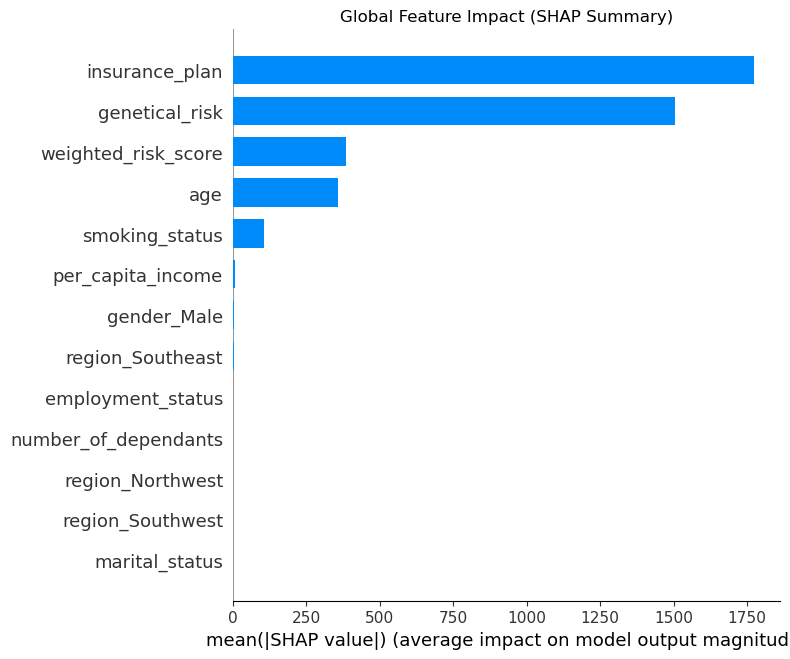

In [157]:
plt.figure(figsize=(10, 6))
plt.title("Global Feature Impact (SHAP Summary)")
shap.summary_plot(shap_values, X_test, plot_type="bar", show=True)

### Local Explainability ( SHAP ). Taking example of first person in test data (shap_values[0])

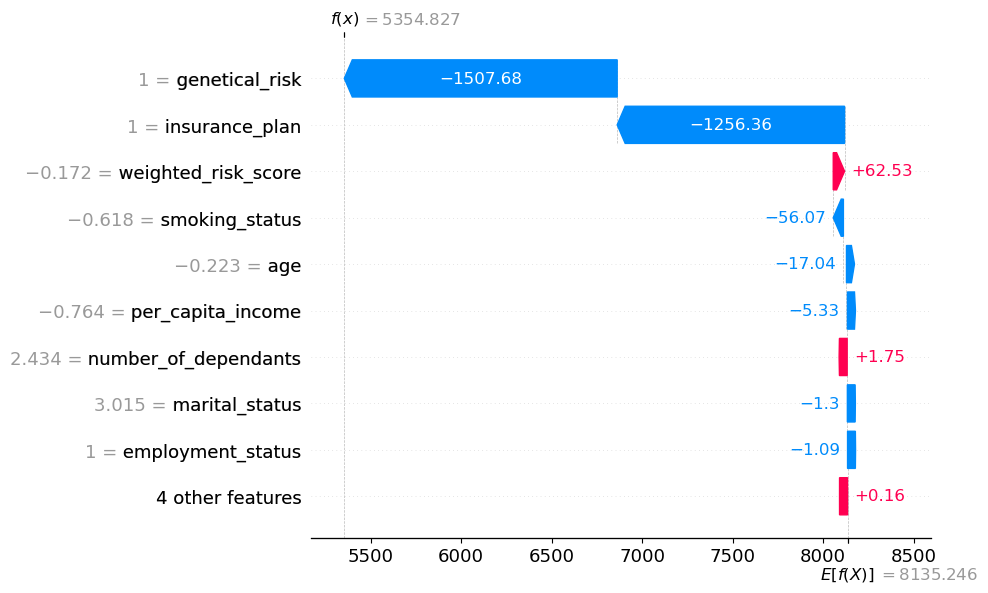

In [158]:
shap.plots.waterfall(shap_values[0])

### Making Pipeline to Deal with One Hot Encoding and Target Mean Encoding 

Odinal Encoding

In [159]:
ordinal_mappings = {
    'insurance_plan': {'Bronze': 1, 'Silver': 2, 'Gold': 3},
    'employment_status': {'Freelancer': 1, 'Salaried': 2, 'Self-Employed': 3}
}

Target Mean Encoding 

In [160]:
target_cols = ['medical_history', 'bmi_category', 'marital_status', 'smoking_status']
target_mean_mappings = {}

for col in target_cols:
    mean_dict = training_data.groupby(col)['annual_premium_amount'].mean().to_dict()
    target_mean_mappings[col] = mean_dict

Saving the Values

In [161]:
master_schema = {
    'ordinal': ordinal_mappings,
    'target_mean': target_mean_mappings
}
joblib.dump(master_schema, 'artifacts/youth_preprocessing_schema.joblib')

print("Data Saved")

Data Saved


### Saving the Scaler we used to use it in our pipeline 

In [162]:
joblib.dump(scaler, 'artifacts/youth_scaler.joblib')
joblib.dump(scaling_cols, 'artifacts/youth_scaling_cols.joblib')

print("saved the scaler")

saved the scaler
